# Financial Fraud Detection — Model Evaluation

## Objective

This is the **final evaluation notebook** for the Financial Fraud Detection project. The purpose of this notebook is to perform a detailed evaluation of the already-trained best model on the **unseen held-out test set**.

**Key points:**
- The model (Logistic Regression) was trained and selected in **Notebook 06**.
- **No retraining** occurs in this notebook.
- Evaluation is performed exclusively on `X_test` and `y_test` — data the model has never seen during training.
- All metrics reported here reflect the model's true generalisation performance.

---
## 1. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


---
## 2. Load Test Data and Model

We load the held-out test set (`X_test`, `y_test`) and the best model selected in Notebook 06.

In [2]:
# Project root (one level up from notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Paths
X_TEST_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'X_test.csv')
Y_TEST_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'y_test.csv')
MODEL_PATH  = os.path.join(PROJECT_ROOT, 'models', 'best_fraud_model.joblib')

# Load data
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH).squeeze()  # Convert to 1-D Series

# Load model
model = joblib.load(MODEL_PATH)

print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"Model type   : {type(model).__name__}")
print(f"Model params : {model.get_params()}")

X_test shape : (10000, 41)
y_test shape : (10000,)
Model type   : LogisticRegression
Model params : {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


---
## 3. Verify Evaluation Data

Before generating predictions, we verify data integrity to ensure a valid evaluation.

In [3]:
# Row count match
assert X_test.shape[0] == y_test.shape[0], "Row count mismatch between X_test and y_test!"
print(f"✓ Row counts match: {X_test.shape[0]} samples")

# No missing values in X_test
assert X_test.isnull().sum().sum() == 0, "X_test contains missing values!"
print(f"✓ No missing values in X_test")

# No infinite values in X_test
assert np.isinf(X_test.values).sum() == 0, "X_test contains infinite values!"
print(f"✓ No infinite values in X_test")

# y_test contains only valid binary labels
assert set(y_test.unique()).issubset({0, 1}), "y_test contains labels other than 0 and 1!"
print(f"✓ y_test contains only valid binary labels: {sorted(y_test.unique())}")

# Class distribution
fraud_count = (y_test == 1).sum()
non_fraud_count = (y_test == 0).sum()
print(f"\nClass distribution in y_test:")
print(f"  Non-Fraud (0): {non_fraud_count} ({non_fraud_count/len(y_test)*100:.2f}%)")
print(f"  Fraud     (1): {fraud_count} ({fraud_count/len(y_test)*100:.2f}%)")

✓ Row counts match: 10000 samples
✓ No missing values in X_test
✓ No infinite values in X_test
✓ y_test contains only valid binary labels: [np.int64(0), np.int64(1)]

Class distribution in y_test:
  Non-Fraud (0): 6787 (67.87%)
  Fraud     (1): 3213 (32.13%)


---
## 4. Generate Final Predictions

Using the already-loaded best model, we generate class predictions and probability estimates on the test set. **No retraining occurs.**

In [4]:
# Generate predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Prediction class distribution
pred_counts = pd.Series(y_pred).value_counts().sort_index()
print("Predicted class distribution:")
print(f"  Non-Fraud (0): {pred_counts.get(0, 0)}")
print(f"  Fraud     (1): {pred_counts.get(1, 0)}")
print(f"\nTotal predictions: {len(y_pred)}")
print(f"Total probabilities: {len(y_prob)}")

Predicted class distribution:
  Non-Fraud (0): 5073
  Fraud     (1): 4927

Total predictions: 10000
Total probabilities: 10000


---
## 5. Confusion Matrix

The confusion matrix shows the counts of correct and incorrect predictions for each class.

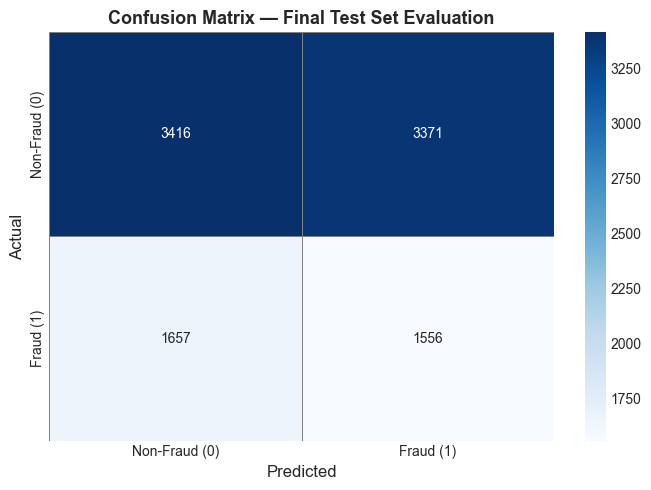

True Negatives  (TN): 3416  — Correctly identified non-fraudulent transactions
False Positives (FP): 3371  — Legitimate transactions incorrectly flagged as fraud
False Negatives (FN): 1657  — Fraudulent transactions missed by the model
True Positives  (TP): 1556  — Correctly identified fraudulent transactions


In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
    yticklabels=['Non-Fraud (0)', 'Fraud (1)'],
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Final Test Set Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Extract and explain components
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — Correctly identified non-fraudulent transactions")
print(f"False Positives (FP): {fp}  — Legitimate transactions incorrectly flagged as fraud")
print(f"False Negatives (FN): {fn}  — Fraudulent transactions missed by the model")
print(f"True Positives  (TP): {tp}  — Correctly identified fraudulent transactions")

---
## 6. Classification Report

The classification report provides precision, recall, and F1-score for each class.

In [6]:
report = classification_report(
    y_test,
    y_pred,
    target_names=['Non-Fraud', 'Fraud']
)

print("Classification Report:")
print("=" * 55)
print(report)

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.67      0.50      0.58      6787
       Fraud       0.32      0.48      0.38      3213

    accuracy                           0.50     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.56      0.50      0.51     10000



**Interpretation (Fraud class focus):**

- **Fraud Precision** indicates the proportion of predicted fraud cases that were actually fraudulent. A low value means many false alarms.
- **Fraud Recall** indicates the proportion of actual fraud cases that the model correctly detected. A higher recall means fewer missed frauds.
- **Fraud F1-Score** is the harmonic mean of precision and recall — a single metric that balances both concerns.

---
## 7. Final Metrics

Individual evaluation metrics calculated on the test set.

In [7]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("Final Evaluation Metrics (Fraud class = positive):")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")

Final Evaluation Metrics (Fraud class = positive):
  Accuracy  : 0.4972
  Precision : 0.3158
  Recall    : 0.4843
  F1-Score  : 0.3823
  ROC-AUC   : 0.4922


---
## 8. ROC Curve

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate against the False Positive Rate at various classification thresholds. The area under this curve (ROC-AUC) summarises the model's ability to discriminate between classes.

- **ROC-AUC = 1.0** → perfect classifier
- **ROC-AUC = 0.5** → random classifier (no discriminative ability)
- **ROC-AUC < 0.5** → classifier performing worse than random

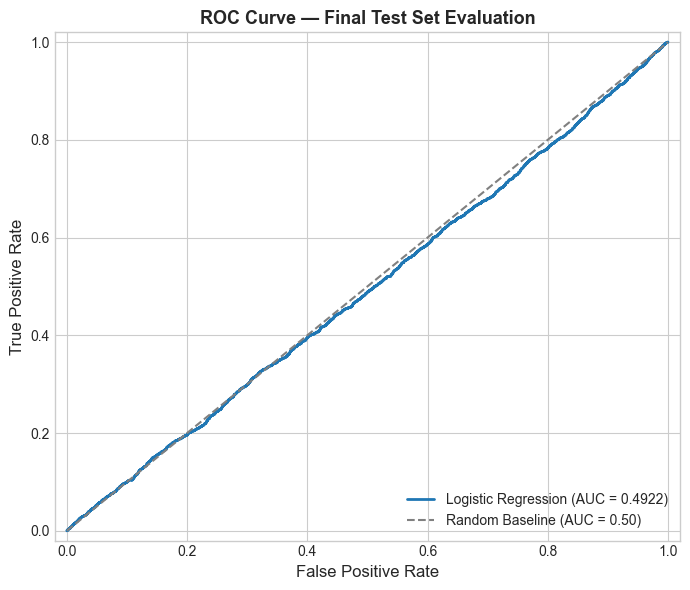

ROC-AUC: 0.4922

The ROC-AUC of ~0.49 is very close to 0.50, indicating that the model's
discriminative ability is approximately equivalent to random classification.


In [8]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Baseline (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Final Test Set Evaluation', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"\nThe ROC-AUC of ~{roc_auc:.2f} is very close to 0.50, indicating that the model's")
print(f"discriminative ability is approximately equivalent to random classification.")

---
## 9. Precision-Recall Curve

The Precision-Recall (PR) curve is particularly important for fraud detection because:

1. **Class imbalance**: Fraud cases are often a minority class. ROC-AUC can be misleadingly optimistic when the negative class dominates.
2. **Cost sensitivity**: In fraud detection, the costs of false negatives (missed fraud) and false positives (legitimate transactions flagged) are very different.
3. **Focus on the positive class**: The PR curve directly evaluates how well the model identifies fraud, without being inflated by the large number of easy-to-classify non-fraud cases.

**Average Precision (AP)** summarises the PR curve as a single number.

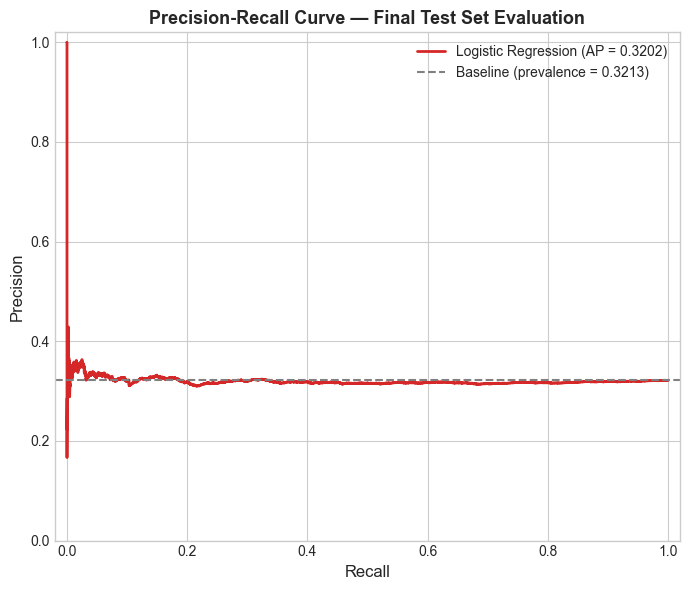

Average Precision (AP): 0.3202


In [9]:
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_curve, prec_curve, color='#d62728', lw=2,
        label=f'Logistic Regression (AP = {avg_precision:.4f})')
# Baseline: prevalence of the positive class
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
           label=f'Baseline (prevalence = {baseline:.4f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Final Test Set Evaluation', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

print(f"Average Precision (AP): {avg_precision:.4f}")

---
## 10. Threshold Analysis

The default classification threshold is 0.50, but adjusting it creates a trade-off:

- **Lower threshold** → more transactions flagged as fraud → higher recall but lower precision (more false positives).
- **Higher threshold** → fewer transactions flagged as fraud → higher precision but lower recall (more missed fraud).

Below, we evaluate a range of thresholds to understand this trade-off.

In [10]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    threshold_results.append({
        'Threshold': t,
        'Precision': round(p, 4),
        'Recall': round(r, 4),
        'F1-Score': round(f, 4)
    })

threshold_df = pd.DataFrame(threshold_results)
print("Threshold Analysis:")
print("=" * 50)
print(threshold_df.to_string(index=False))

Threshold Analysis:
 Threshold  Precision  Recall  F1-Score
       0.2     0.3213  1.0000    0.4863
       0.3     0.3213  1.0000    0.4863
       0.4     0.3213  1.0000    0.4863
       0.5     0.3158  0.4843    0.3823
       0.6     0.0000  0.0000    0.0000
       0.7     0.0000  0.0000    0.0000
       0.8     0.0000  0.0000    0.0000


**Interpretation:**

Changing the classification threshold creates a **precision-recall trade-off**. Lowering the threshold catches more fraud cases (higher recall) but at the cost of more false alarms (lower precision). Raising the threshold reduces false alarms but risks missing actual fraud.

The choice of threshold in a production setting depends on business requirements — specifically, the relative cost of missing a fraudulent transaction versus the cost of investigating a false alarm.

---
## 11. Model Performance Interpretation

### Key Findings

Based on the evaluation results above:

- **Fraud Precision (~0.32):** Only about 1 in 3 transactions flagged as fraud are actually fraudulent. This means a high volume of false positives — legitimate transactions would be incorrectly flagged.

- **Fraud Recall (~0.48):** The model detects roughly half of all actual fraud cases. This means about half of all fraudulent transactions go undetected.

- **Fraud F1-Score (~0.38):** The low F1-score reflects the combined weakness of both precision and recall for the fraud class.

- **ROC-AUC (~0.49):** This is approximately equal to random classification (0.50). The model has **virtually no ability to discriminate** between fraudulent and non-fraudulent transactions based on the probability scores.

- **False Positives:** A large number of legitimate transactions are incorrectly flagged as fraud, which would cause unnecessary customer friction in a real system.

- **False Negatives:** A substantial proportion of actual fraud cases are missed, which represents financial risk.

### Is the Model Useful as a Production Fraud Detector?

**No.** The model's performance is not suitable for production deployment. The ROC-AUC of ~0.49 indicates that the model's predicted probabilities carry no meaningful signal for ranking transactions by fraud risk. The model's performance is fundamentally limited by the **weak predictive relationship between the available features and the fraud label** in this synthetic dataset.

---
## 12. Limitations

The following limitations should be considered when interpreting these results:

1. **Synthetic dataset:** The data used in this project is synthetically generated and may not reflect the statistical patterns found in real-world financial transaction data.

2. **Weak feature-target predictive signal:** The features in the dataset exhibit very low correlation with the fraud label. This fundamentally limits any model's ability to learn a meaningful decision boundary.

3. **ROC-AUC close to random:** An ROC-AUC of ~0.49 indicates that the model cannot effectively rank transactions by fraud likelihood, which is a critical requirement for a fraud detection system.

4. **Generalisation to real-world fraud:** Model performance on this synthetic dataset may not generalise to real-world financial fraud detection, where different feature distributions and stronger fraud signals are typically present.

5. **Threshold choice involves business trade-offs:** The optimal classification threshold depends on the specific costs of false positives (customer inconvenience, operational cost) versus false negatives (financial loss from undetected fraud). This is a business decision, not a purely statistical one.

6. **Need for richer features:** Real-world fraud detection systems typically rely on additional signals such as transaction velocity, geolocation anomalies, device fingerprinting, behavioural biometrics, and network-based features — none of which are available in this dataset.

---
## 13. Final Evaluation Summary

In [11]:
summary_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Average Precision'],
    'Value': [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(roc_auc, 4),
        round(avg_precision, 4)
    ]
}
summary_df = pd.DataFrame(summary_data)
print("Final Evaluation Summary")
print("=" * 35)
print(summary_df.to_string(index=False))

Final Evaluation Summary
           Metric  Value
         Accuracy 0.4972
        Precision 0.3158
           Recall 0.4843
         F1-Score 0.3823
          ROC-AUC 0.4922
Average Precision 0.3202


### Conclusion

The Logistic Regression model was selected as the best-performing model in Notebook 06, primarily based on its F1-Score. Among the three models evaluated (Logistic Regression, Random Forest, Gradient Boosting), it was the only model that demonstrated any ability to predict the fraud class.

However, the overall performance remains limited. The ROC-AUC of approximately 0.49 confirms that the model's discriminative ability is no better than random chance. This is not a failure of the modelling approach, but rather a reflection of the **weak predictive signal** present in this synthetic dataset.

For a production fraud detection system, significantly stronger features and real-world transaction data would be required to achieve meaningful performance.

---
## 14. Final Verification

In [12]:
# Final verification checks
assert model is not None, "Model failed to load!"
print("✓ Model loaded successfully")

assert len(y_pred) == len(y_test), "Prediction count does not match test set count!"
print(f"✓ Prediction count matches test set count: {len(y_pred)}")

assert len(y_prob) == len(y_test), "Probability count does not match test set count!"
print(f"✓ Probability count matches test set count: {len(y_prob)}")

assert np.isfinite(accuracy) and np.isfinite(precision) and np.isfinite(recall) \
       and np.isfinite(f1) and np.isfinite(roc_auc), "One or more metrics are not finite!"
print("✓ All metrics are finite")

assert not np.any(np.isnan(y_pred)), "Predictions contain NaN values!"
assert not np.any(np.isnan(y_prob)), "Probabilities contain NaN values!"
print("✓ No NaN values in predictions or probabilities")

print("\n" + "=" * 50)
print("Notebook 07 evaluation completed successfully.")
print("=" * 50)

✓ Model loaded successfully
✓ Prediction count matches test set count: 10000
✓ Probability count matches test set count: 10000
✓ All metrics are finite
✓ No NaN values in predictions or probabilities

Notebook 07 evaluation completed successfully.
